## Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import random
from sklearn.metrics import precision_recall_fscore_support,  confusion_matrix
import seaborn as sns
import json

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce GTX 1650


##  Load Data

In [2]:
# Paths
ROOT_DIR = "/home/vishn/Documents/5/ML/Code/Project/output/"
PARTAWARE_DIR = os.path.join(ROOT_DIR, "PartAwarePooling/")
INPUT_DIR = os.path.join(ROOT_DIR, "input/")
OUTPUT_DIR = "/home/vishn/Documents/5/ML/Code/Project/output/models/"
RESULTS_DIR = "/home/vishn/Documents/5/ML/Code/Project/output/results/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


# Load features
train_features = np.fromfile(os.path.join(PARTAWARE_DIR, "train_fused_features.npy"), 
                             dtype=np.float32).reshape(312186, 2048)
val_features = np.fromfile(os.path.join(PARTAWARE_DIR, "val_fused_features.npy"), 
                          dtype=np.float32).reshape(52490, 2048)

# Load labels
train_df = pd.read_csv(os.path.join(INPUT_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(INPUT_DIR, "validation.csv"))
train_labels = train_df['category_id'].values - 1  
val_labels = val_df['category_id'].values - 1

# Convert to tensors
train_features_t = torch.from_numpy(train_features).float()
train_labels_t = torch.from_numpy(train_labels).long()
val_features_t = torch.from_numpy(val_features).float()
val_labels_t = torch.from_numpy(val_labels).long()

# Class statistics
unique_classes = torch.unique(train_labels_t).sort()[0]
class_indices = {c.item(): (train_labels_t == c).nonzero(as_tuple=True)[0] for c in unique_classes}
class_counts = {c: len(idx) for c, idx in class_indices.items()}

## Embedded Meta Learning

In [3]:
class OptimalEmbeddingNetwork(nn.Module):
    """Embedding network optimized for few-shot learning"""
    def __init__(self, input_dim=2048, embed_dim=512):
        super().__init__()
        
        # Progressive dimensionality reduction with skip connections
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(1024, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )
        
        self.layer3 = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x, normalize=True):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        if normalize:
            x = F.normalize(x, p=2, dim=1)
        
        return x

class PrototypicalClassifier(nn.Module):
    """Classifier using prototypical networks approach"""
    def __init__(self, embed_dim=512, num_classes=13):
        super().__init__()
        self.num_classes = num_classes
        # Learnable class prototypes
        self.prototypes = nn.Parameter(torch.randn(num_classes, embed_dim))
        # Temperature for scaling distances
        self.temperature = nn.Parameter(torch.ones(1))
        
    def forward(self, embeddings):
        # Normalize prototypes
        prototypes_norm = F.normalize(self.prototypes, p=2, dim=1)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        
        # Compute cosine similarity (equivalent to negative distance for normalized vectors)
        similarities = torch.mm(embeddings_norm, prototypes_norm.t())
        
        # Scale by temperature
        logits = similarities / torch.clamp(self.temperature, min=0.01, max=10.0)
        
        return logits


##  Meta-Learning Functions

In [4]:
def compute_prototypes(embeddings, labels, num_classes):
    """Compute class prototypes from embeddings"""
    prototypes = torch.zeros(num_classes, embeddings.shape[1], 
                            device=embeddings.device, dtype=embeddings.dtype)
    
    for c in range(num_classes):
        mask = (labels == c)
        if mask.sum() > 0:
            prototypes[c] = embeddings[mask].mean(dim=0)
    
    return prototypes

def create_episode(features, labels, class_indices, n_way, k_shot, q_query):
    """Create a single episode for meta-learning"""
    available_classes = list(class_indices.keys())
    if len(available_classes) < n_way:
        return None, None, None, None, None
    
    # Sample N classes
    sampled_classes = random.sample(available_classes, n_way)
    
    support_features, support_labels = [], []
    query_features, query_labels = [], []
    
    for idx, c in enumerate(sampled_classes):
        class_idx = class_indices[c]
        if len(class_idx) < k_shot + q_query:
            return None, None, None, None, None
        
        # Sample K+Q examples
        perm = torch.randperm(len(class_idx))[:k_shot + q_query]
        selected = class_idx[perm]
        
        # Support set
        support_features.append(features[selected[:k_shot]])
        support_labels.append(torch.full((k_shot,), idx, dtype=torch.long))
        
        # Query set
        query_features.append(features[selected[k_shot:]])
        query_labels.append(torch.full((q_query,), idx, dtype=torch.long))
    
    support_f = torch.cat(support_features, dim=0)
    support_l = torch.cat(support_labels, dim=0)
    query_f = torch.cat(query_features, dim=0)
    query_l = torch.cat(query_labels, dim=0)
    
    # Shuffle
    s_perm = torch.randperm(len(support_f))
    q_perm = torch.randperm(len(query_f))
    
    return (support_f[s_perm], support_l[s_perm], 
            query_f[q_perm], query_l[q_perm], 
            sampled_classes)

def meta_train_step(embedding_net, features, labels, class_indices, 
                   n_way, k_shot, q_query, optimizer):
    """Single meta-training step"""
    embedding_net.train()
    optimizer.zero_grad()
    
    # Create episode
    sup_f, sup_l, que_f, que_l, _ = create_episode(
        features, labels, class_indices, n_way, k_shot, q_query
    )
    
    if sup_f is None:
        return None, None
    
    sup_f, que_f = sup_f.to(device), que_f.to(device)
    sup_l, que_l = sup_l.to(device), que_l.to(device)
    
    # Compute embeddings
    sup_emb = embedding_net(sup_f)
    que_emb = embedding_net(que_f)
    
    # Compute prototypes
    prototypes = compute_prototypes(sup_emb, sup_l, n_way)
    
    # Compute distances (negative squared Euclidean)
    dists = torch.cdist(que_emb, prototypes, p=2.0) ** 2
    logits = -dists
    
    # Loss
    loss = F.cross_entropy(logits, que_l)
    
    # Backward
    loss.backward()
    torch.nn.utils.clip_grad_norm_(embedding_net.parameters(), max_norm=1.0)
    optimizer.step()
    
    # Accuracy
    acc = (logits.argmax(dim=1) == que_l).float().mean().item()
    
    return loss.item(), acc


## Phase 1: Meta-Learning (Episodic Training)

In [ ]:
# Hyperparameters
INPUT_DIM = 2048
EMBED_DIM = 512
N_WAY = 5
K_SHOT = 10  
Q_QUERY = 15
META_EPISODES = 1500
META_LR = 0.001
EVAL_EVERY = 100

# Create embedding network
embedding_net = OptimalEmbeddingNetwork(INPUT_DIM, EMBED_DIM).to(device)
meta_optimizer = torch.optim.Adam(embedding_net.parameters(), lr=META_LR)
meta_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(meta_optimizer, T_max=META_EPISODES)


# Training
train_losses, train_accs, val_losses, val_accs = [], [], [], []
best_val_acc = 0.0

for episode in tqdm(range(1, META_EPISODES + 1), desc="Meta-Training"):
    loss, acc = meta_train_step(
        embedding_net, train_features_t, train_labels_t, class_indices,
        N_WAY, K_SHOT, Q_QUERY, meta_optimizer
    )
    
    if loss is not None:
        train_losses.append(loss)
        train_accs.append(acc)
    
    meta_scheduler.step()
    
    # Validation
    if episode % EVAL_EVERY == 0:
        embedding_net.eval()
        val_class_indices = {c.item(): (val_labels_t == c).nonzero(as_tuple=True)[0] 
                           for c in torch.unique(val_labels_t)}
        
        with torch.no_grad():
            sup_f, sup_l, que_f, que_l, _ = create_episode(
                val_features_t, val_labels_t, val_class_indices,
                N_WAY, K_SHOT, Q_QUERY
            )
            
            if sup_f is not None:
                sup_f, que_f = sup_f.to(device), que_f.to(device)
                sup_l, que_l = sup_l.to(device), que_l.to(device)
                
                sup_emb = embedding_net(sup_f)
                que_emb = embedding_net(que_f)
                
                prototypes = compute_prototypes(sup_emb, sup_l, N_WAY)
                dists = torch.cdist(que_emb, prototypes, p=2.0) ** 2
                logits = -dists
                
                v_loss = F.cross_entropy(logits, que_l)
                v_acc = (logits.argmax(dim=1) == que_l).float().mean().item()
                
                val_losses.append(v_loss.item())
                val_accs.append(v_acc)
                
                if v_acc > best_val_acc:
                    best_val_acc = v_acc
                    torch.save({
                        'embedding_net': embedding_net.state_dict(),
                        'episode': episode,
                        'best_val_acc': best_val_acc
                    }, os.path.join(OUTPUT_DIR, 'optimal_embedding_net.pt'))
                
                print(f"\nEp {episode}/{META_EPISODES} | "
                      f"Train: L={loss:.3f} A={acc:.1%} | "
                      f"Val: L={v_loss:.3f} A={v_acc:.1%} (Best={best_val_acc:.1%})")
        
        embedding_net.train()

print(f"Best meta-learning accuracy: {best_val_acc:.2%}")

Meta-Training:   7%|▋         | 109/1500 [00:05<00:17, 79.57it/s]


Ep 100/1500 | Train: L=1.391 A=40.0% | Val: L=1.461 A=34.7% (Best=34.7%)


Meta-Training:  15%|█▍        | 219/1500 [00:07<00:14, 89.77it/s]


Ep 200/1500 | Train: L=1.452 A=42.7% | Val: L=1.442 A=41.3% (Best=41.3%)


Meta-Training:  21%|██        | 311/1500 [00:08<00:12, 93.97it/s]

...


Ep 1300/1500 | Train: L=1.393 A=48.0% | Val: L=1.186 A=64.0% (Best=64.0%)


Meta-Training:  94%|█████████▍| 1410/1500 [00:20<00:01, 84.72it/s]


Ep 1400/1500 | Train: L=1.381 A=45.3% | Val: L=1.377 A=49.3% (Best=64.0%)


Meta-Training: 100%|██████████| 1500/1500 [00:21<00:00, 71.31it/s]


Ep 1500/1500 | Train: L=1.378 A=42.7% | Val: L=1.518 A=28.0% (Best=64.0%)
Best meta-learning accuracy: 64.00%


##  Phase 2: Fine-tuning on Full Dataset

In [6]:

# Load best embedding network
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'optimal_embedding_net.pt'))
embedding_net.load_state_dict(checkpoint['embedding_net'])

# Create prototypical classifier
classifier = PrototypicalClassifier(EMBED_DIM, num_classes=13).to(device)

# Initialize prototypes from training data
embedding_net.eval()
with torch.no_grad():
    # Compute embeddings for all training data (in batches)
    batch_size = 1024
    all_embeddings = []
    for i in range(0, len(train_features_t), batch_size):
        batch = train_features_t[i:i+batch_size].to(device)
        emb = embedding_net(batch)
        all_embeddings.append(emb.cpu())
    all_embeddings = torch.cat(all_embeddings, dim=0)
    
    # Compute class prototypes
    init_prototypes = compute_prototypes(all_embeddings, train_labels_t, 13)
    classifier.prototypes.data = init_prototypes.to(device)
    

# Dataloaders
train_dataset = TensorDataset(train_features_t, train_labels_t)
val_dataset = TensorDataset(val_features_t, val_labels_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=4)

# Optimizer - fine-tune both embedding and classifier
ft_optimizer = torch.optim.Adam([
    {'params': embedding_net.parameters(), 'lr': 0.0001},  # Lower LR for embedding
    {'params': classifier.parameters(), 'lr': 0.001}  # Higher LR for classifier
], weight_decay=0.0001)

ft_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ft_optimizer, mode='max', patience=3, factor=0.5
)

# Fine-tuning
NUM_EPOCHS = 25
best_val_f1 = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

def train_epoch(emb_net, classifier, loader, optimizer):
    emb_net.train()
    classifier.train()
    total_loss, correct, total = 0, 0, 0
    
    for features, labels in tqdm(loader, desc="Training", leave=False):
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        embeddings = emb_net(features)
        logits = classifier(embeddings)
        loss = F.cross_entropy(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(emb_net.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), 100.0 * correct / total

def evaluate(emb_net, classifier, loader):
    emb_net.eval()
    classifier.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for features, labels in tqdm(loader, desc="Evaluating", leave=False):
            features, labels = features.to(device), labels.to(device)
            
            embeddings = emb_net(features)
            logits = classifier(embeddings)
            loss = F.cross_entropy(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = 100.0 * correct / total
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return total_loss / len(loader), acc, precision, recall, f1, all_preds, all_labels

print(f"\nFine-tuning for {NUM_EPOCHS} epochs...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print("-" * 80)
    
    train_loss, train_acc = train_epoch(embedding_net, classifier, train_loader, ft_optimizer)
    val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = evaluate(
        embedding_net, classifier, val_loader
    )
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | "
          f"P: {val_precision:.3f} | R: {val_recall:.3f} | F1: {val_f1:.4f}")
    
    ft_scheduler.step(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'embedding_net': embedding_net.state_dict(),
            'classifier': classifier.state_dict(),
            'epoch': epoch,
            'best_val_f1': best_val_f1
        }, os.path.join(OUTPUT_DIR, 'optimal_fewshot_model.pt'))
        print(f"Saved best model (F1: {val_f1:.4f})")
    print()

print(f"Best Validation F1: {best_val_f1:.4f}")


Fine-tuning for 25 epochs...

Epoch 1/25
--------------------------------------------------------------------------------


Train → Loss: 1.7943 | Acc: 37.91%
Val   → Loss: 1.4973 | Acc: 46.17% | P: 0.447 | R: 0.462 | F1: 0.4407
Saved best model (F1: 0.4407)

Epoch 2/25
--------------------------------------------------------------------------------


Train → Loss: 1.5730 | Acc: 43.28%
Val   → Loss: 1.4152 | Acc: 49.05% | P: 0.474 | R: 0.491 | F1: 0.4698
Saved best model (F1: 0.4698)

Epoch 3/25
--------------------------------------------------------------------------------


Train → Loss: 1.5173 | Acc: 45.10%
Val   → Loss: 1.3855 | Acc: 50.21% | P: 0.488 | R: 0.502 | F1: 0.4841
Saved best model (F1: 0.4841)

Epoch 4/25
--------------------------------------------------------------------------------


Train → Loss: 1.4766 | Acc: 46.46%
Val   → Loss: 1.3549 | Acc: 51.36% | P: 0.501 | R: 0.514 | F1: 0.4962
Saved best model (F1: 0.4962)

Epoch 5/25
--------------------------------------------------------------------------------


...

Train → Loss: 1.1443 | Acc: 58.06%
Val   → Loss: 1.3689 | Acc: 53.30% | P: 0.523 | R: 0.533 | F1: 0.5181

Epoch 22/25
--------------------------------------------------------------------------------


Train → Loss: 1.0765 | Acc: 60.55%
Val   → Loss: 1.4128 | Acc: 52.88% | P: 0.521 | R: 0.529 | F1: 0.5211

Epoch 23/25
--------------------------------------------------------------------------------


Train → Loss: 1.0541 | Acc: 61.48%
Val   → Loss: 1.4078 | Acc: 53.37% | P: 0.524 | R: 0.534 | F1: 0.5255
Saved best model (F1: 0.5255)

Epoch 24/25
--------------------------------------------------------------------------------


Train → Loss: 1.0421 | Acc: 61.73%
Val   → Loss: 1.4270 | Acc: 53.26% | P: 0.527 | R: 0.533 | F1: 0.5235

Epoch 25/25
--------------------------------------------------------------------------------


Train → Loss: 1.0280 | Acc: 62.25%
Val   → Loss: 1.4330 | Acc: 52.97% | P: 0.525 | R: 0.530 | F1: 0.5228

Best Validation F1: 0.5255


##  Final Evaluation & Results

In [7]:
# Load best model
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'optimal_fewshot_model.pt'))
embedding_net.load_state_dict(checkpoint['embedding_net'])
classifier.load_state_dict(checkpoint['classifier'])

# Final evaluation
val_loss, val_acc, val_precision, val_recall, val_f1, val_preds, val_labels = evaluate(
    embedding_net, classifier, val_loader
)

print(f"\nValidation Set:")
print(f"  Accuracy:  {val_acc:.2f}%")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")
print(f"  F1-Score:  {val_f1:.4f}")

# Per-class metrics
CATEGORY_NAMES = {
    0: "short sleeve top", 1: "long sleeve top", 2: "short sleeve outwear",
    3: "long sleeve outwear", 4: "vest", 5: "sling", 6: "shorts",
    7: "trousers", 8: "skirt", 9: "short sleeve dress",
    10: "long sleeve dress", 11: "vest dress", 12: "sling dress"
}

precision, recall, f1, support = precision_recall_fscore_support(
    val_labels, val_preds, labels=list(range(13)), zero_division=0
)

print(f"{'Category':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-"*80)
for i in range(13):
    print(f"{CATEGORY_NAMES[i]:<25} {precision[i]:>10.3f} {recall[i]:>10.3f} "
          f"{f1[i]:>10.3f} {support[i]:>10}")

# Save results
results = {
    'meta_learning_accuracy': float(best_val_acc),
    'final_validation_accuracy': float(val_acc),
    'final_validation_f1': float(val_f1),
    'final_validation_precision': float(val_precision),
    'final_validation_recall': float(val_recall),
    'per_class_f1': {CATEGORY_NAMES[i]: float(f1[i]) for i in range(13)}
}

with open(os.path.join(RESULTS_DIR, 'optimal_fewshot_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n Results saved to: {RESULTS_DIR}/optimal_fewshot_results.json")

Evaluating:   0%|          | 0/206 [00:00<?, ?it/s]


Validation Set:
  Accuracy:  53.37%
  Precision: 0.5245
  Recall:    0.5337
  F1-Score:  0.5255
Category                   Precision     Recall   F1-Score    Support
--------------------------------------------------------------------------------
short sleeve top               0.574      0.684      0.624      12556
long sleeve top                0.447      0.446      0.446       5966
short sleeve outwear           0.286      0.042      0.074        142
long sleeve outwear            0.506      0.421      0.459       2011
vest                           0.411      0.266      0.323       2113
sling                          0.336      0.124      0.181        322
shorts                         0.461      0.501      0.480       4167
trousers                       0.693      0.729      0.711       9586
skirt                          0.536      0.441      0.484       6522
short sleeve dress             0.393      0.344      0.367       3127
long sleeve dress              0.279      0.232     

##  Visualization

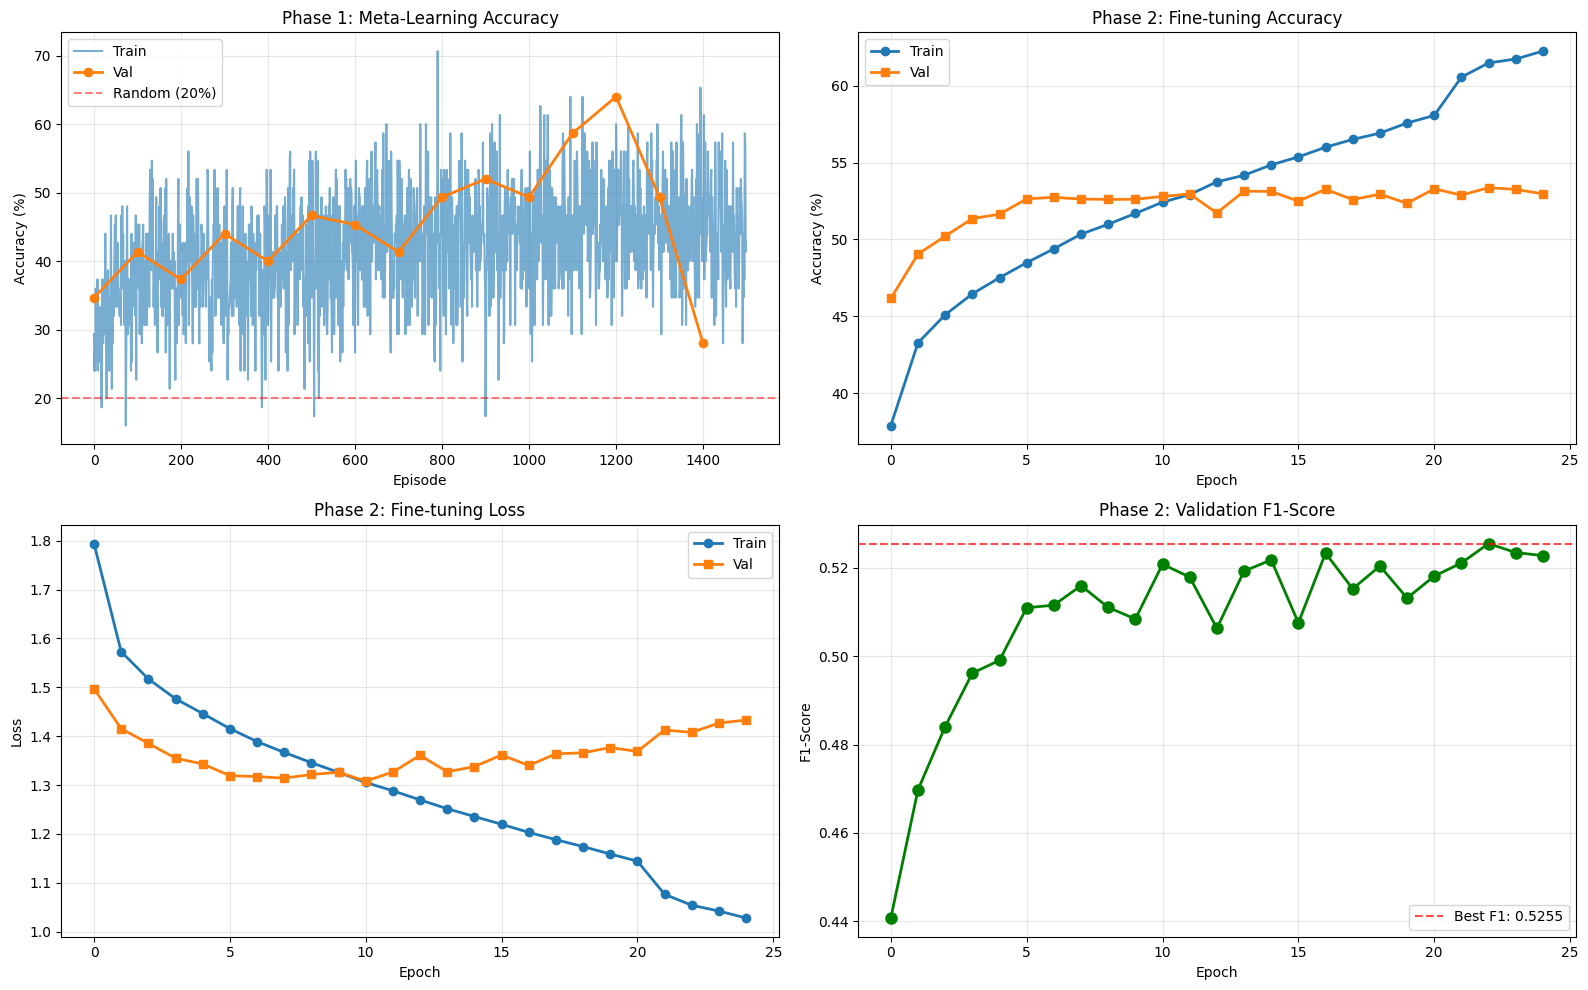

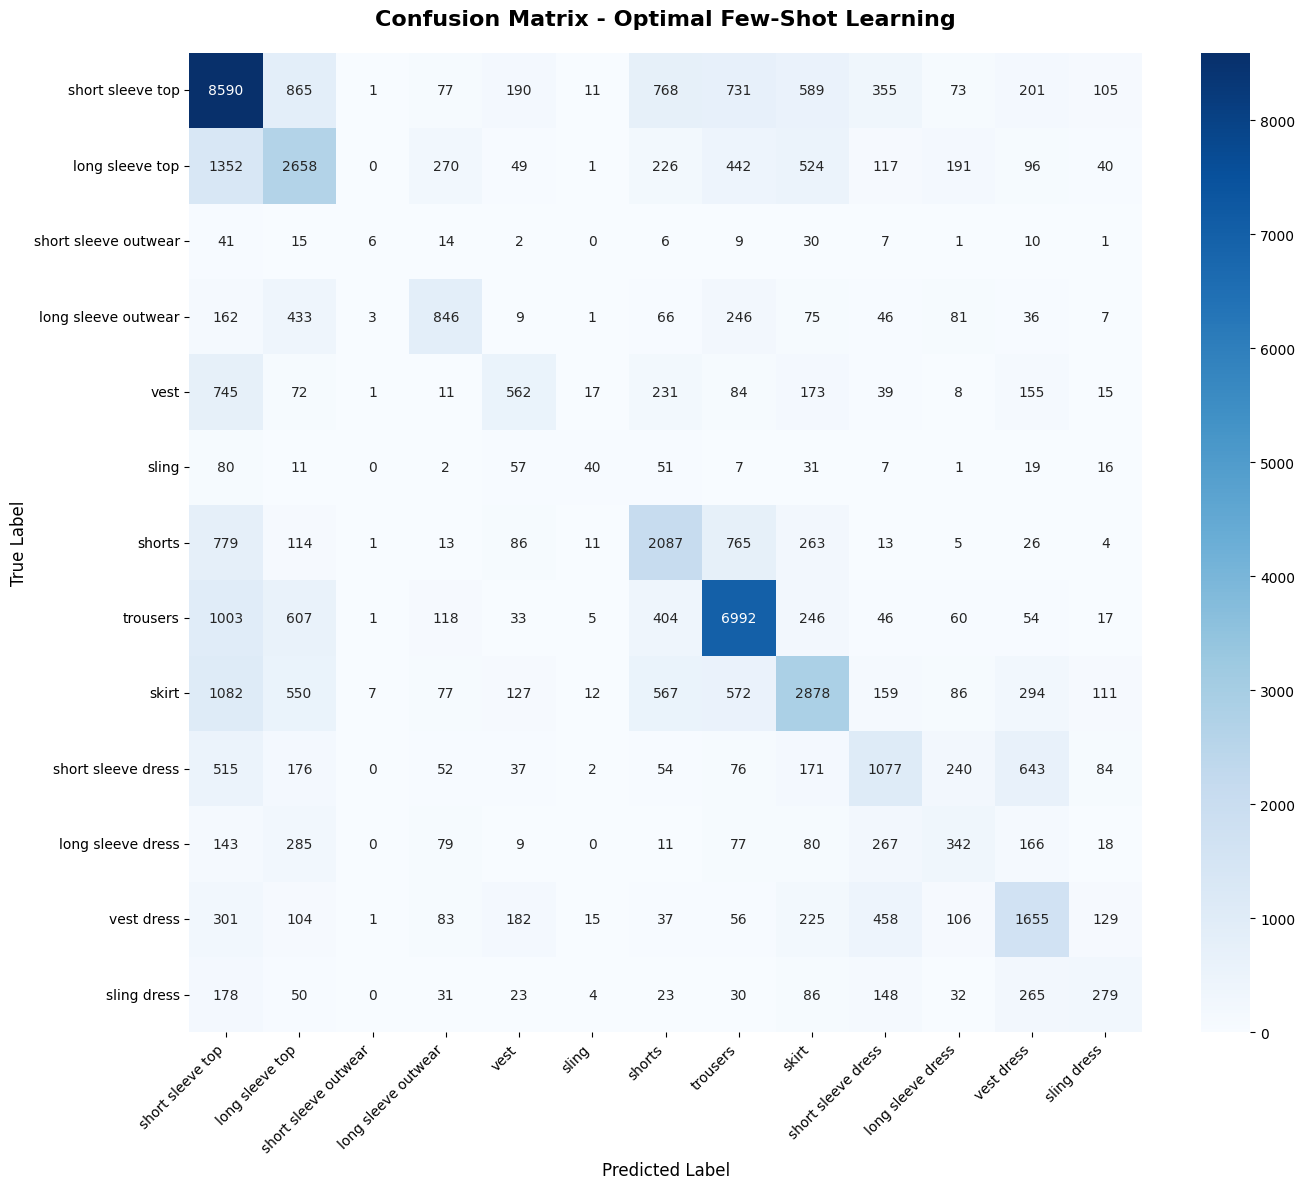

In [8]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Meta-learning curves
axes[0, 0].plot([a*100 for a in train_accs], alpha=0.6, label='Train')
if val_accs:
    val_episodes = [i * EVAL_EVERY for i in range(len(val_accs))]
    axes[0, 0].plot(val_episodes, [a*100 for a in val_accs], 'o-', label='Val', linewidth=2)
axes[0, 0].axhline(y=20, color='r', linestyle='--', alpha=0.5, label='Random (20%)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Phase 1: Meta-Learning Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Fine-tuning accuracy
axes[0, 1].plot(history['train_acc'], 'o-', label='Train', linewidth=2)
axes[0, 1].plot(history['val_acc'], 's-', label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Phase 2: Fine-tuning Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Fine-tuning loss
axes[1, 0].plot(history['train_loss'], 'o-', label='Train', linewidth=2)
axes[1, 0].plot(history['val_loss'], 's-', label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Phase 2: Fine-tuning Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# F1 score progression
axes[1, 1].plot(history['val_f1'], 'o-', color='green', linewidth=2, markersize=8)
axes[1, 1].axhline(y=best_val_f1, color='r', linestyle='--', alpha=0.7, 
                   label=f'Best F1: {best_val_f1:.4f}')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('Phase 2: Validation F1-Score')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'optimal_fewshot_training_curves.png'), dpi=150)
plt.show()

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CATEGORY_NAMES[i] for i in range(13)],
            yticklabels=[CATEGORY_NAMES[i] for i in range(13)])
plt.title('Confusion Matrix - Optimal Few-Shot Learning', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'optimal_fewshot_confusion_matrix.png'), dpi=150)
plt.show()
